Intent Classification Model Training using ModernBERT

This notebook implements a complete training pipeline for an intent classification model using ModernBERT, a transformer-based language model. The model learns to classify user intents from input examples defined in a JSON file and leverages contextual language understanding to achieve higher accuracy than traditional NLP approaches.

The notebook covers the full machine learning workflow, including data loading, preprocessing, dataset preparation, model training, evaluation, and model export. The resulting model can be used to identify user intents in a movie chatbot and support accurate movie recommendations and conversational interactions.

Notebook Overview

This notebook is structured into several sections, each focusing on a key aspect of building an intent classification model for a movie chatbot. The goal is to classify user queries into predefined intents (e.g., movie_action, movie_comedy, movie_recommendation) to enable relevant and personalized responses.

Unlike traditional Bag-of-Words approaches, ModernBERT uses contextual embeddings that capture the meaning of words based on their surrounding context. This allows the model to better understand variations in user phrasing, synonyms, and natural language expressions.

In [1]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.1 MB/s eta 0:00:00


In [19]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

In [2]:
# Imports
import json
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
import evaluate

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from torch.utils.data import Dataset

In [3]:
INTENT_DESCRIPTIONS = {

    "greeting":
    "user is starting a conversation, greeting someone, saying hello, hi, hey, good morning, or opening an interaction",

    "goodbye":
    "user is ending a conversation, saying goodbye, bye, farewell, see you later, or closing an interaction",

    "movie_recommendation":
    "user is asking for movie recommendations, films to watch, entertainment suggestions, genres, actors, trending movies, or movies based on mood",

    "learning_recommendation":
    "user is asking for learning resources, tutorials, programming courses, coding help, educational content, or study material",

    "fallback":
    "user is asking for something outside supported capabilities such as weather, booking, math, politics, translation, music, navigation, food ordering, or general unsupported tasks"
}

In [21]:
!git clone https://github.com/pramendraindian/movie-agent.git
%cd movie-agent

Cloning into 'movie-agent'...
remote: Enumerating objects: 425, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 425 (delta 66), reused 71 (delta 27), pack-reused 270 (from 1)
Receiving objects: 100% (425/425), 24.16 MiB | 14.94 MiB/s, done.
Resolving deltas: 100% (208/208), done.
/content/movie-agent/movie-agent


In [5]:
# ==================================================
# Config
# ==================================================

MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 128
DATA_PATH = "app/data/updated_intents.json"
SAVE_PATH = "intent_model"
PLOT_DIR = Path("Notebooks")
NEGATIVES_PER_EXAMPLE = 3
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [6]:
def generate_pairs(examples: list[dict]) -> tuple[list[str], list[str], list[int]]:
    sentence1, sentence2, labels = [], [], []
    all_intents = list(INTENT_DESCRIPTIONS.keys())

    for ex in examples:
        text = ex["text"]
        correct_intent = ex["intent"]

        sentence1.append(text)
        sentence2.append(INTENT_DESCRIPTIONS[correct_intent])
        labels.append(1)

        negative_intents = [i for i in all_intents if i != correct_intent]
        sampled_negatives = random.sample(
            negative_intents,
            min(NEGATIVES_PER_EXAMPLE, len(negative_intents)),
        )
        for negative_intent in sampled_negatives:
            sentence1.append(text)
            sentence2.append(INTENT_DESCRIPTIONS[negative_intent])
            labels.append(0)

    return sentence1, sentence2, labels

In [7]:
class IntentPairDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return evaluate.load("accuracy").compute(predictions=predictions, references=labels)

In [9]:
def predict_intent(text: str, model, tokenizer) -> tuple[str, float]:
    scores = {}
    model.eval()
    with torch.no_grad():
        for intent, description in INTENT_DESCRIPTIONS.items():
            inputs = tokenizer(
                text,
                description,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH,
            )
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)
            scores[intent] = probs[0][1].item()
    best_intent, confidence = max(scores.items(), key=lambda item: item[1])
    return best_intent, confidence

In [10]:
def plot_training_curves(log_history: list[dict], output_path: Path) -> None:
    train_losses = [
        entry["loss"] for entry in log_history if "loss" in entry and "eval_loss" not in entry
    ]
    eval_losses = [
        (entry["epoch"], entry["eval_loss"])
        for entry in log_history
        if "eval_loss" in entry
    ]
    eval_accuracies = [
        (entry["epoch"], entry["eval_accuracy"])
        for entry in log_history
        if "eval_accuracy" in entry
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if train_losses:
        axes[0].plot(range(1, len(train_losses) + 1), train_losses, color="#e74c3c", linewidth=1.8)
        axes[0].set_title("Training Loss (step-level)")
        axes[0].set_xlabel("Logging step")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True, alpha=0.3)

    if eval_losses:
        epochs, losses = zip(*eval_losses)
        axes[1].plot(epochs, losses, color="#3498db", linewidth=1.8, marker="o", label="Eval loss")
    if eval_accuracies:
        epochs, accs = zip(*eval_accuracies)
        ax2 = axes[1].twinx()
        ax2.plot(epochs, [a * 100 for a in accs], color="#2ecc71", linewidth=1.8, marker="s", label="Pair accuracy")
        ax2.set_ylabel("Pair accuracy (%)")
        ax2.legend(loc="upper right")

    axes[1].set_title("Validation Metrics per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Eval loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved training curves → {output_path}")

In [11]:
def plot_confusion_matrix(y_true, y_pred, labels, output_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("Predicted intent")
    ax.set_ylabel("True intent")
    ax.set_title("ModernBERT Intent Confusion Matrix (utterance-level val set)")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved confusion matrix → {output_path}")

In [12]:
def main() -> None:
    with open(DATA_PATH, encoding="utf-8") as f:
        examples = json.load(f)["examples"]

    train_examples, val_examples = train_test_split(
        examples,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=[ex["intent"] for ex in examples],
    )

    train_s1, train_s2, train_labels = generate_pairs(train_examples)
    val_s1, val_s2, val_labels = generate_pairs(val_examples)

    print(f"Examples: train={len(train_examples)}, val={len(val_examples)}")
    print(f"Pairs: train={len(train_labels)}, val={len(val_labels)}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    train_encodings = tokenizer(train_s1, train_s2, truncation=True, max_length=MAX_LENGTH)
    val_encodings = tokenizer(val_s1, val_s2, truncation=True, max_length=MAX_LENGTH)

    train_dataset = IntentPairDataset(train_encodings, train_labels)
    val_dataset = IntentPairDataset(val_encodings, val_labels)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    training_args = TrainingArguments(
        output_dir="./results",
        learning_rate=2e-5,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        warmup_ratio=0.1,
        fp16=torch.cuda.is_available(),
        save_total_limit=2,
        report_to="none",
        seed=RANDOM_SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    plot_training_curves(
        trainer.state.log_history,
        PLOT_DIR / "bert_training_curves.png",
    )

    intent_labels = list(INTENT_DESCRIPTIONS.keys())
    y_true, y_pred = [], []
    for ex in val_examples:
        pred, _ = predict_intent(ex["text"], model, tokenizer)
        y_true.append(ex["intent"])
        y_pred.append(pred)

    print("\nUtterance-level validation report:")
    print(classification_report(y_true, y_pred, labels=intent_labels, zero_division=0))

    plot_confusion_matrix(
        y_true,
        y_pred,
        intent_labels,
        PLOT_DIR / "bert_confusion_matrix.png",
    )

    model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
    with open(f"{SAVE_PATH}/meta.pkl", "wb") as f:
        pickle.dump(
            {
                "strategy": "sentence_pair",
                "intent_descriptions": INTENT_DESCRIPTIONS,
                "model_name": MODEL_NAME,
                "max_length": MAX_LENGTH,
                "threshold": 0.65,
            },
            f,
        )

    print("\nTraining complete")

In [13]:
if __name__ == "__main__":
    main()

Examples: train=72, val=18
Pairs: train=288, val=72


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.678384,0.566916,0.722222
2,0.564049,0.459901,0.833333
3,0.447489,0.382962,0.805556
4,0.261015,0.301385,0.861111
5,0.175126,0.251128,0.902778


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Saved training curves → Notebooks/bert_training_curves.png

Utterance-level validation report:
                         precision    recall  f1-score   support

               greeting       0.67      0.67      0.67         3
                goodbye       1.00      0.50      0.67         2
   movie_recommendation       1.00      1.00      1.00         6
learning_recommendation       1.00      1.00      1.00         4
               fallback       0.75      1.00      0.86         3

               accuracy                           0.89        18
              macro avg       0.88      0.83      0.84        18
           weighted avg       0.90      0.89      0.88        18

Saved confusion matrix → Notebooks/bert_confusion_matrix.png



Training complete


bert_training_curves.png


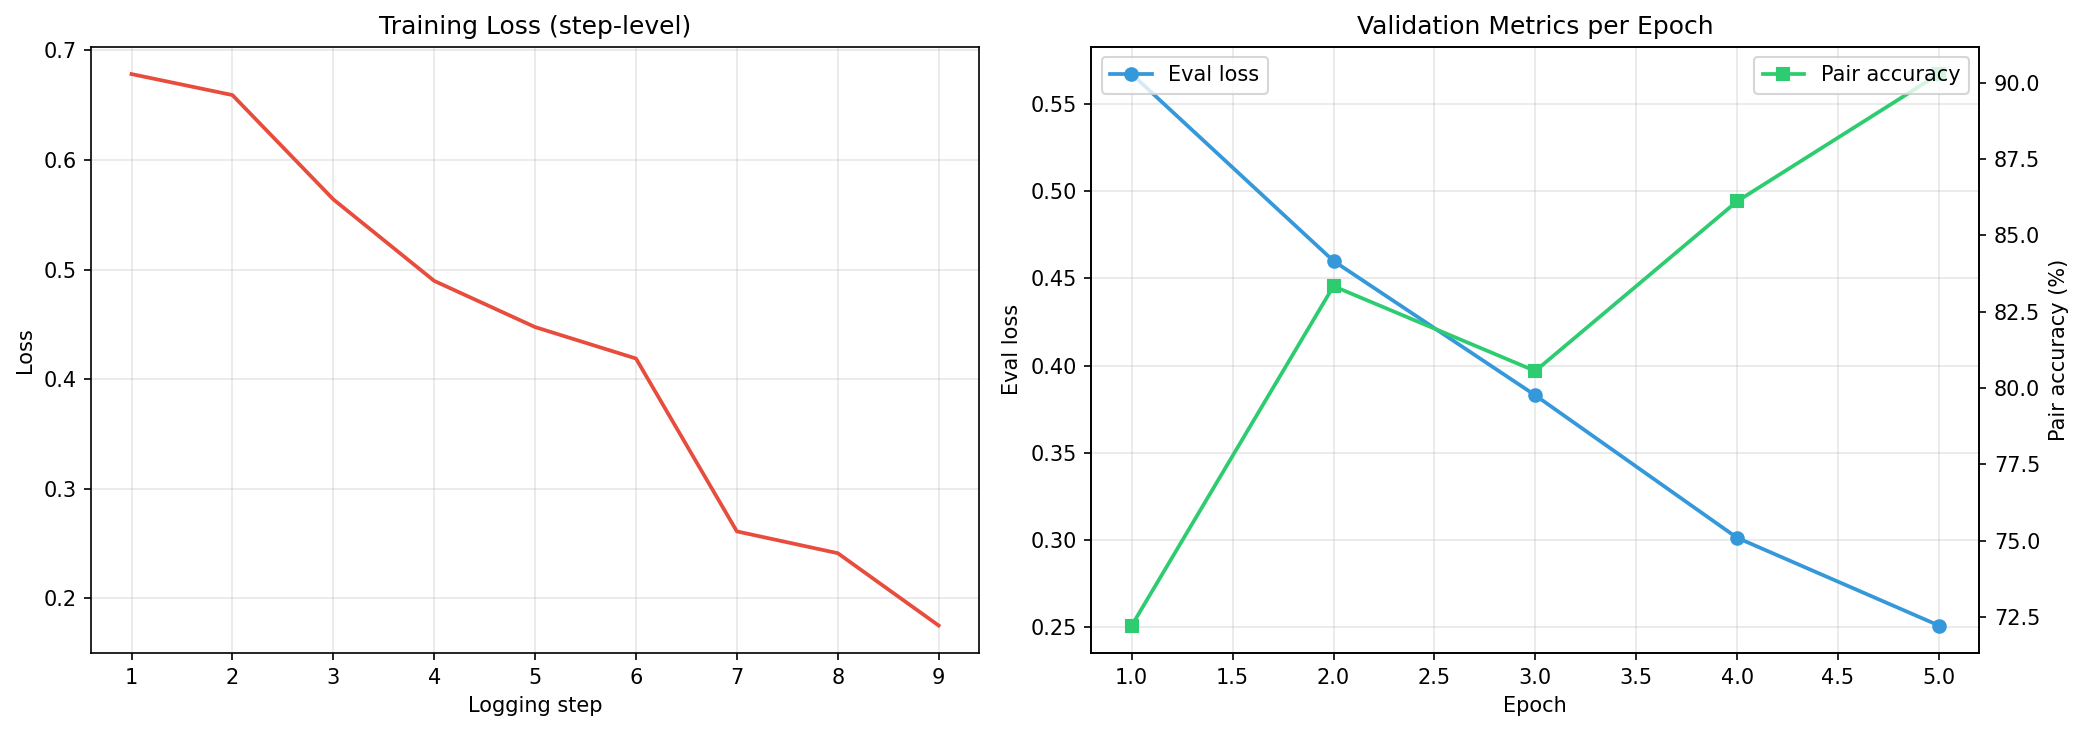

bert_confusion_matrix.png


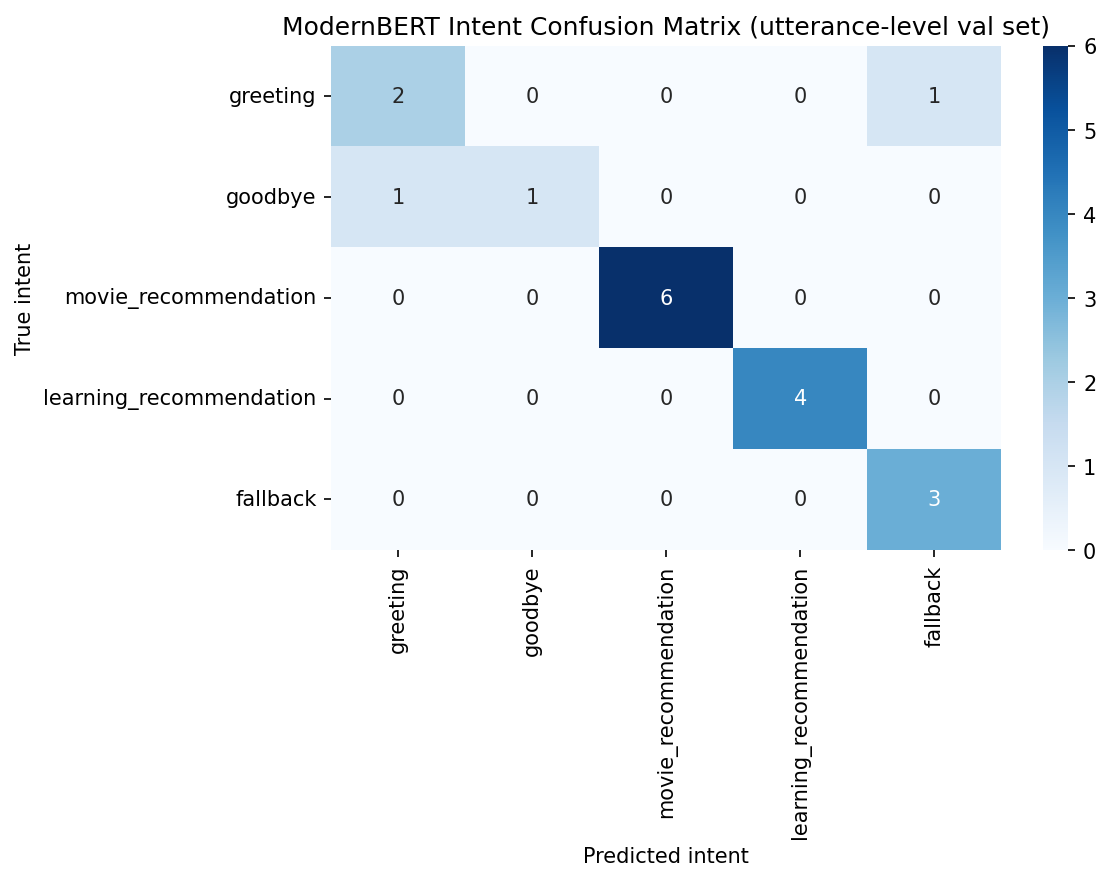

In [18]:
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path("Notebooks")

for name in ["bert_training_curves.png", "bert_confusion_matrix.png"]:
    path = plot_dir / name
    if path.exists():
        print(name)
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path}")

In [14]:
import pickle
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

# ==================================================
# Load metadata
# ==================================================

with open("intent_model/meta.pkl", "rb") as f:
    meta = pickle.load(f)

INTENT_DESCRIPTIONS = meta["intent_descriptions"]
MODEL_NAME = meta["model_name"]
MAX_LENGTH = meta["max_length"]

In [15]:
# ==================================================
# Load tokenizer + model
# ==================================================

tokenizer = AutoTokenizer.from_pretrained(
    "intent_model"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "intent_model"
)

model.eval()

ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (1-21): 21 x ModernBertEncoderLayer(
       

In [16]:
# ==================================================
# Predict
# ==================================================

def predict_intent(text, threshold=0.65):

    scores = {}

    with torch.no_grad():

        for intent, description in INTENT_DESCRIPTIONS.items():

            inputs = tokenizer(

                text,
                description,

                return_tensors="pt",

                truncation=True,

                max_length=MAX_LENGTH
            )

            outputs = model(**inputs)

            probs = torch.nn.functional.softmax(
                outputs.logits,
                dim=1
            )

            match_probability = probs[0][1].item()

            scores[intent] = match_probability

    # ==================================================
    # Sort scores
    # ==================================================

    sorted_scores = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    print("\nPredictions:\n")

    for intent, score in sorted_scores:
        print(f"{intent}: {score:.4f}")

    best_intent = sorted_scores[0][0]

    confidence = sorted_scores[0][1]

    if confidence < threshold:
        return "fallback", confidence

    return best_intent, confidence

In [17]:
test_sentences = [
    "suggest comedy movie",
    "hi",
    "how to learn python",
    "book me a cab",
    "see you later",
]
for text in test_sentences:
    print(f"\nYou: {text}")
    intent, confidence = predict_intent(text)
    print(f"Predicted Intent: {intent}")
    print(f"Confidence: {confidence:.4f}")


You: suggest comedy movie

Predictions:

movie_recommendation: 0.9212
fallback: 0.1328
learning_recommendation: 0.0333
greeting: 0.0096
goodbye: 0.0033
Predicted Intent: movie_recommendation
Confidence: 0.9212

You: hi

Predictions:

greeting: 0.8820
goodbye: 0.2635
fallback: 0.1766
learning_recommendation: 0.0695
movie_recommendation: 0.0615
Predicted Intent: greeting
Confidence: 0.8820

You: how to learn python

Predictions:

learning_recommendation: 0.8550
fallback: 0.2070
movie_recommendation: 0.0318
greeting: 0.0251
goodbye: 0.0054
Predicted Intent: learning_recommendation
Confidence: 0.8550

You: book me a cab

Predictions:

fallback: 0.6320
movie_recommendation: 0.1119
learning_recommendation: 0.0606
greeting: 0.0270
goodbye: 0.0141
Predicted Intent: fallback
Confidence: 0.6320

You: see you later

Predictions:

goodbye: 0.6574
greeting: 0.4605
fallback: 0.0967
learning_recommendation: 0.0482
movie_recommendation: 0.0424
Predicted Intent: goodbye
Confidence: 0.6574


In [22]:
import json

path = "Notebooks/NLP_train_predict_modern_bert.ipynb"  # your actual filename
with open(path, encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata (main fix)
nb.get("metadata", {}).pop("widgets", None)

# Remove widget outputs from cells (optional but helps)
for cell in nb.get("cells", []):
    outputs = cell.get("outputs", [])
    cell["outputs"] = [
        o for o in outputs
        if not (
            o.get("output_type") == "display_data"
            and "application/vnd.jupyter.widget-view+json" in o.get("data", {})
        )
    ]

out_path = "Notebooks/NLP_train_predict_modern_bert.ipynb"  # clean name
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("Cleaned notebook saved →", out_path)

Cleaned notebook saved → Notebooks/NLP_train_predict_modern_bert.ipynb
